# **Credit Card Churning Customers Data Analysis**

## Features

* **Customer Age**
* **Gender**
* **Dependent_Count** - How many dependents the customer 
* **Education Level**
* **Marital Status**
* **Income Category** 
* **Months On Book** - How long the customer has been using the credit card service

* **Total Relationship Count** - Number of products the customer has with the bank (e.g., savings, loans, credit card).

* **Months Inactive 12 mon** - Number of months (in the last 12) where the customer had no activity.

* **Contacts Count 12 mon** - How many times the customer contacted the bank in the last 12 months

* **Credit Limit** - Maximum credit available on the card
* **Total Revolving Balance** - Amount the customer is carrying month‑to‑month (not paid off)

* **Avgerag Open To Buy** - Credit_Limit minus Total_Revolving_Bal. Essentially: how much credit they still have available.

* **Total_Amt_Chng_Q4_Q1** - Change in total transaction amount from Q1 to Q4. Measures spending trend (increasing or decreasing).

* **Total_Trans_Amt** - Total amount spent in the last 12 months
* **Total_Trans_Count** - Total number of transactions in the last 12 months
* **Total_Ct_Chng_Q4_Q1** - Change in transaction count from Q1 to Q4



## Target

**Attrition_Flag** - Indication of a customer leaving or staying on the credit card services

## Inputs

* Cleaned_Data and Transformed_Data

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-'

# Section 1

Section 1 content

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
df = pd.read_csv("Data/Cleaned_Data/Cleaned_Data.csv")
df.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048


In [6]:
df_transformed = pd.read_csv("Data/Cleaned_Data/Transformed_Data.csv")
df_transformed.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Attrition_Flag_Existing Customer,Education_Level_encoded,Card_Category_encoded
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39.0,5,...,42,1.172,0.061,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44.0,6,...,33,1.172,0.105,0.0,0.0,1.0,0.0,1.0,4.0,0.0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4,...,20,1.172,0.000,1.0,1.0,0.0,0.0,1.0,4.0,0.0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34.0,3,...,20,1.172,0.760,0.0,0.0,0.0,1.0,1.0,2.0,0.0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21.0,5,...,28,1.172,0.000,1.0,1.0,0.0,0.0,1.0,1.0,0.0
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3,...,24,0.846,0.311,1.0,1.0,0.0,0.0,1.0,4.0,0.0
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46.0,6,...,31,0.722,0.066,1.0,1.0,0.0,0.0,1.0,0.0,2.0
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2,...,36,0.714,0.048,1.0,0.0,0.0,1.0,1.0,2.0,1.0


In [7]:
df_transformed["Card_Category"].unique()

array(['Blue', 'Gold', 'Silver', 'Platinum'], dtype=object)

In [8]:
df_transformed["Education_Level"].unique()

array(['High School', 'Graduate', 'Uneducated', 'Unknown', 'College',
       'Post-Graduate', 'Doctorate'], dtype=object)

---

# Section 2

Bivariate Analysis

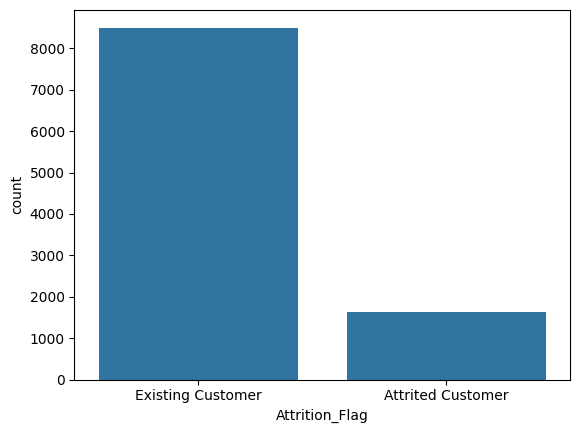

In [9]:
sns.countplot(data=df_transformed, x="Attrition_Flag")
plt.show()

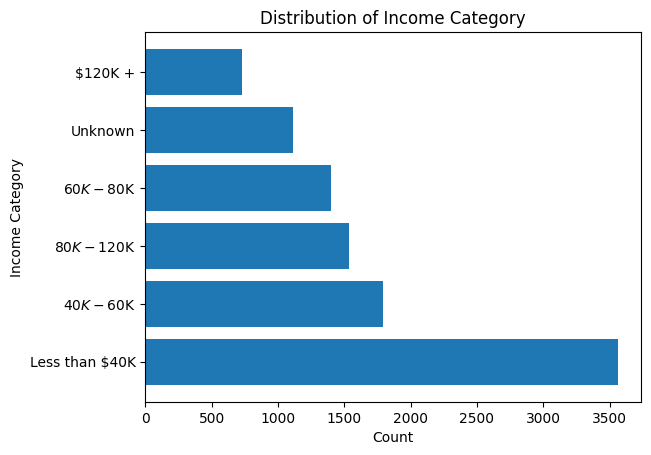

In [10]:
categorial_count=df['Income_Category'].value_counts()
plt.barh(y=categorial_count.index, width=categorial_count.values)
plt.title("Distribution of Income Category")
plt.xlabel("Count")
plt.ylabel("Income Category")
plt.show()
# sns.countplot(data=df_transformed, x="Income_Category")
# plt.tight_layout()
# plt.show()

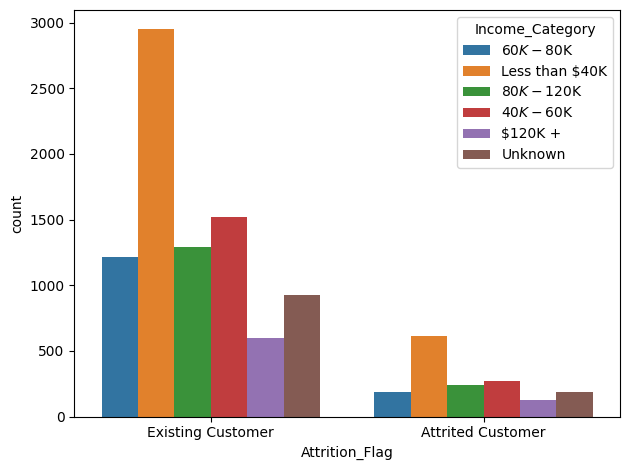

In [11]:
sns.countplot(data=df_transformed,x="Attrition_Flag", hue="Income_Category")
plt.tight_layout()
plt.show()

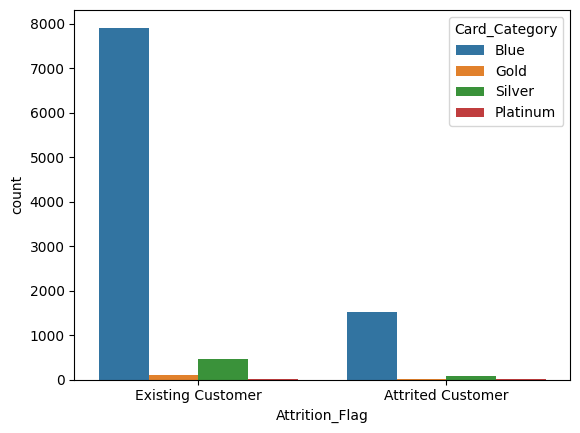

In [12]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Card_Category")
plt.show()

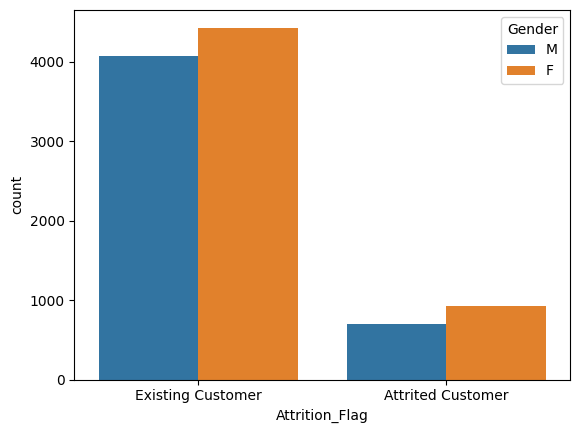

In [13]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Gender")
plt.show()

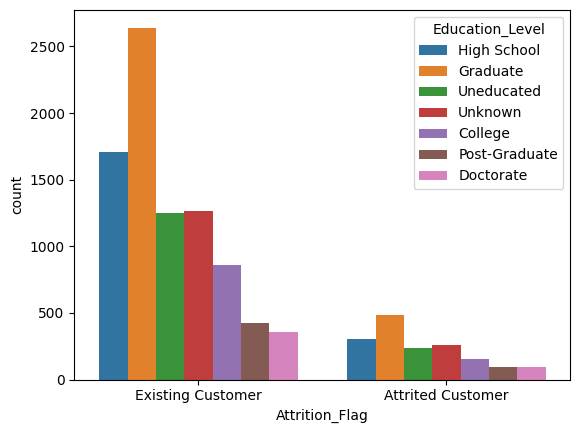

In [14]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Education_Level")
plt.show()

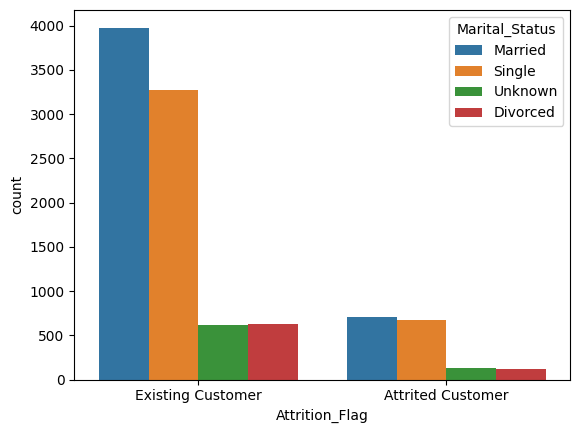

In [15]:
sns.countplot(data=df_transformed, x="Attrition_Flag", hue="Marital_Status")
plt.show()

**Attrition Flag Barplot**
The data is heavily imbalanced which can make comparativr analysis difficult 

**Income Distribution** 
Less than $40K is the largest group, $120K+ is the smallest. This tells you the customer base is mostly lower‑income which is somewhat expected as you'd assume lower income are more likely to take things out on credits. The shape of the bars is almost identical for both groups. Lower‑income customers dominate both existing and attrited groups. So income is not a strong churn predictor.

**Card Category**
Blue card holders make up the vast majority of both groups, very few customers have Silver, Gold, or Platinum cards this is somewhat expected as more premium cards whilst hold benefits normally have hgiher interst rates.
Attrition patterns look similar across card categories. This means card tier does not meaningfully distinguish churners.

**Gender**
Slightly more females than males both genders show similar attrition patterns therefore Gender is not a meaningful churn predictor.

**Martial Status**
Attrition proportions look similar therefore Marital status is not a strong churn driver

All demographic variables (gender, education, marital status, income, card category) show very similar distributions for existing vs attrited customers. This means demographics are not driving churn

<Figure size 1000x600 with 0 Axes>

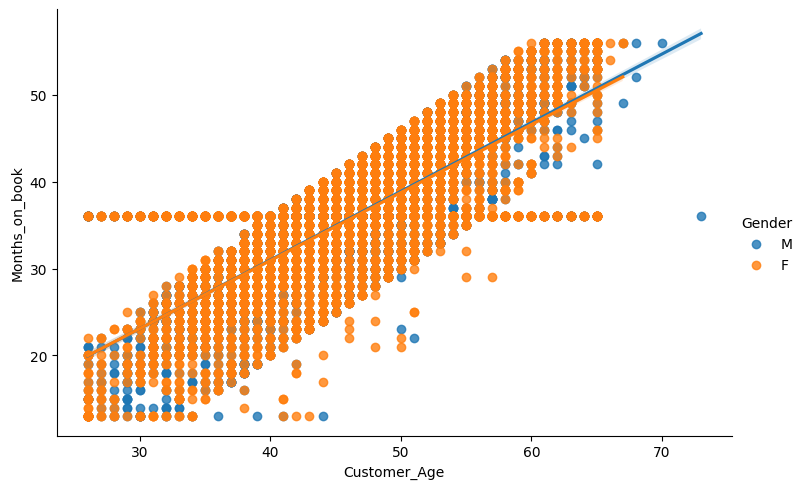

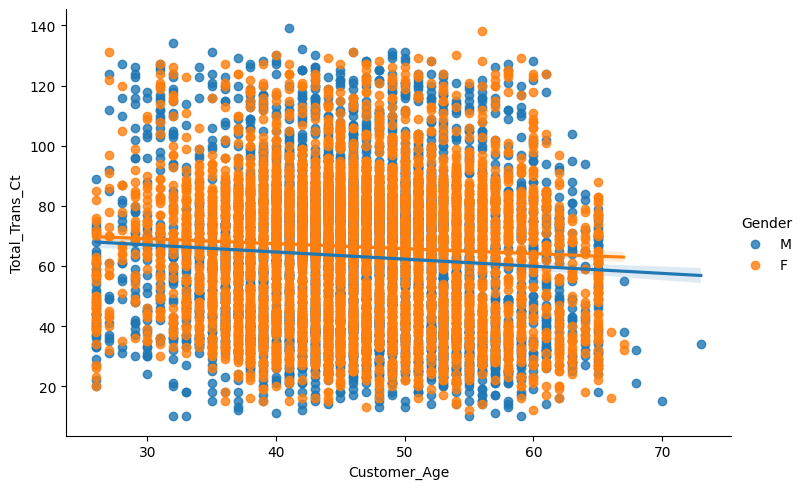

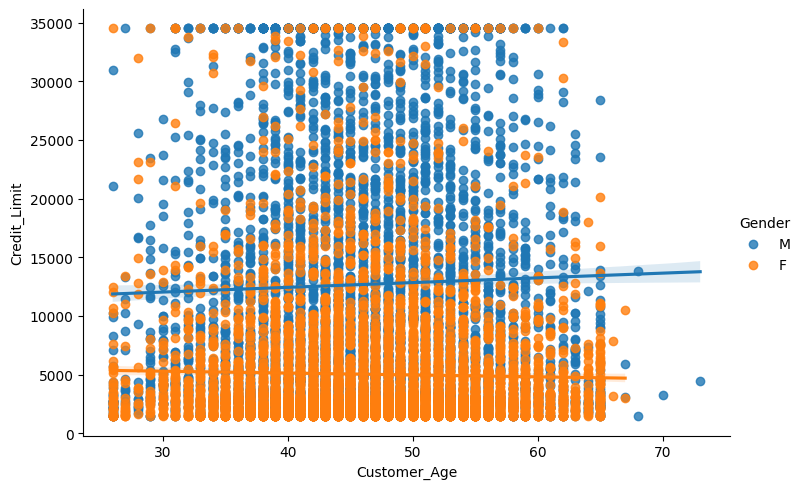

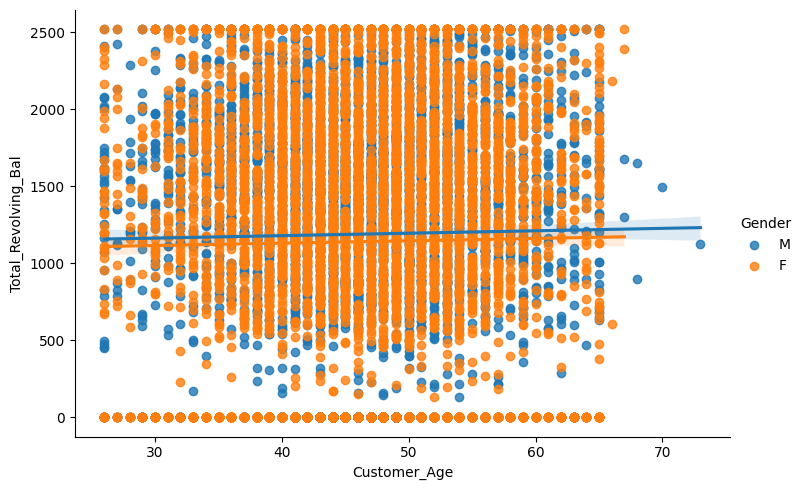

In [16]:
plt.figure(figsize=(10,6))

sns.lmplot(data=df, y='Months_on_book', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Total_Trans_Ct', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Credit_Limit', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
sns.lmplot(data=df, y='Total_Revolving_Bal', x='Customer_Age', hue='Gender', height=5, aspect=1.5)
plt.show()

**Customer_Age v Month_on_book**
There is a clear positive relationship showing older customers tend to have been with the bank longer. The regression line slopes upward with both genders follow the same pattern.

**Customer_Age vs Total_Transaction_Count**
A slight negative trend as age increases, transaction count decreases. Younger customers tend to be more active the relationship is weak but visible.

**Customer Age vs Credit Limit**
A slight positive trend showing older customers tend to have higher credit limits. This makes sense as older customers often have longer credit histories therefore higher credit scores which allows them to get higher credit amounts

**Customer Age vs Total Revolving Balance**
No real relationship between age and revolving balance the regression line is almost flat.

In [17]:
df_corr=df_transformed[['Credit_Limit','Customer_Age','Dependent_count','Months_on_book','Total_Relationship_Count','Total_Trans_Amt','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Gender_M','Marital_Status_Married','Education_Level_encoded','Card_Category_encoded','Attrition_Flag_Existing Customer']].corr(method='pearson')
df_corr

,Credit_Limit,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Education_Level_encoded,Card_Category_encoded,Attrition_Flag_Existing Customer
Credit_Limit,1.000000,0.002661,0.063830,0.007977,-0.063668,0.168939,0.068944,-0.007484,-0.518439,0.439319,-0.055394,-0.004554,0.439291,0.031269
Customer_Age,0.002661,1.000000,-0.122254,0.787856,-0.010931,-0.046446,-0.067097,-0.027717,0.007114,-0.017312,0.047364,-0.002369,-0.018235,-0.018203
Dependent_count,0.063830,-0.122254,1.000000,-0.106605,-0.039076,0.025046,0.049912,0.012386,-0.037135,0.004563,0.014385,0.000472,0.030469,-0.018991
Months_on_book,0.007977,0.787856,-0.106605,1.000000,-0.009707,-0.037688,-0.049937,-0.026631,-0.007056,-0.006797,0.032151,0.005617,-0.013007,-0.013538
Total_Relationship_Count,-0.063668,-0.010931,-0.039076,-0.009707,1.000000,-0.347229,-0.241891,0.038028,0.067663,0.003157,0.017001,0.000766,-0.094077,0.150005
Total_Trans_Amt,0.168939,-0.046446,0.025046,-0.037688,-0.347229,1.000000,0.807192,0.136507,-0.083034,0.024890,-0.063030,-0.007460,0.196003,0.168598
Total_Trans_Ct,0.068944,-0.067097,0.049912,-0.049937,-0.241891,0.807192,1.000000,0.195717,0.002838,-0.067454,-0.123911,-0.004307,0.134275,0.371403
Total_Ct_Chng_Q4_Q1,-0.007484,-0.027717,0.012386,-0.026631,0.038028,0.136507,0.195717,1.000000,0.084179,-0.020749,0.001193,-0.019913,-0.005207,0.327238
Avg_Utilization_Ratio,-0.518439,0.007114,-0.037135,-0.007056,0.067663,-0.083034,0.002838,0.084179,1.000000,-0.257851,0.049684,-0.001849,-0.198711,0.178410
Gender_M,0.439319,-0.017312,0.004563,-0.006797,0.003157,0.024890,-0.067454,-0.020749,-0.257851,1.000000,0.011427,-0.005087,0.080093,0.037272


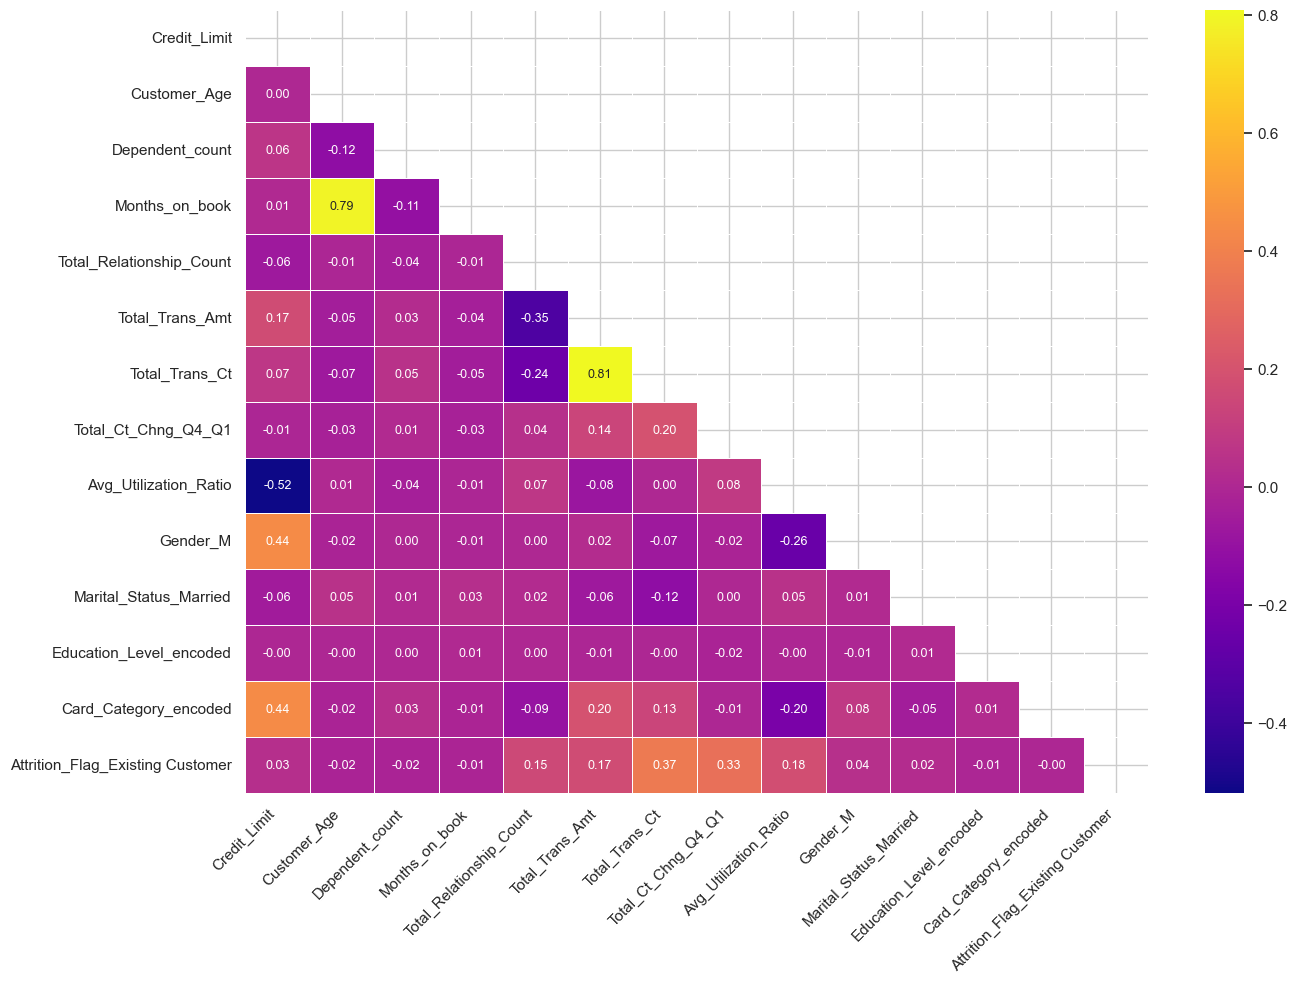

In [18]:
mask=np.zeros_like(df_corr,dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))  # bigger canvas spreads annotation text
sns.heatmap(
    df_corr,
    mask=mask,
    annot=True,
    cmap="plasma",
    linewidths=0.5,
    annot_kws={"size": 9},
    fmt=".2f"  # shorter numbers reduce crowding
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='Total_Trans_Ct', ylabel='Attrition_Flag'>

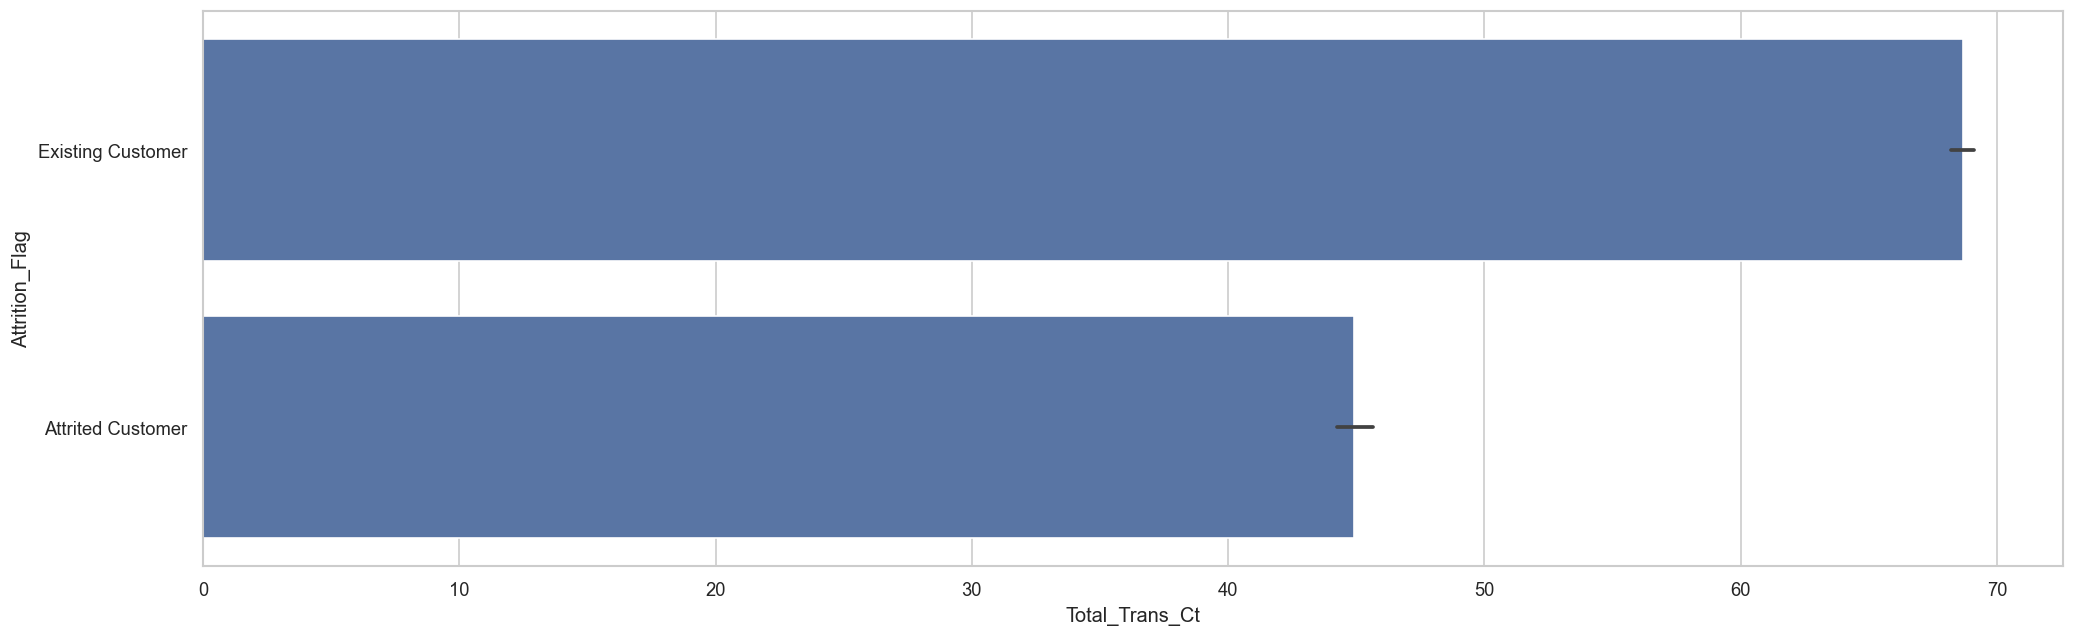

In [19]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, x='Total_Trans_Ct', y='Attrition_Flag')

<Axes: xlabel='Total_Ct_Chng_Q4_Q1', ylabel='Attrition_Flag'>

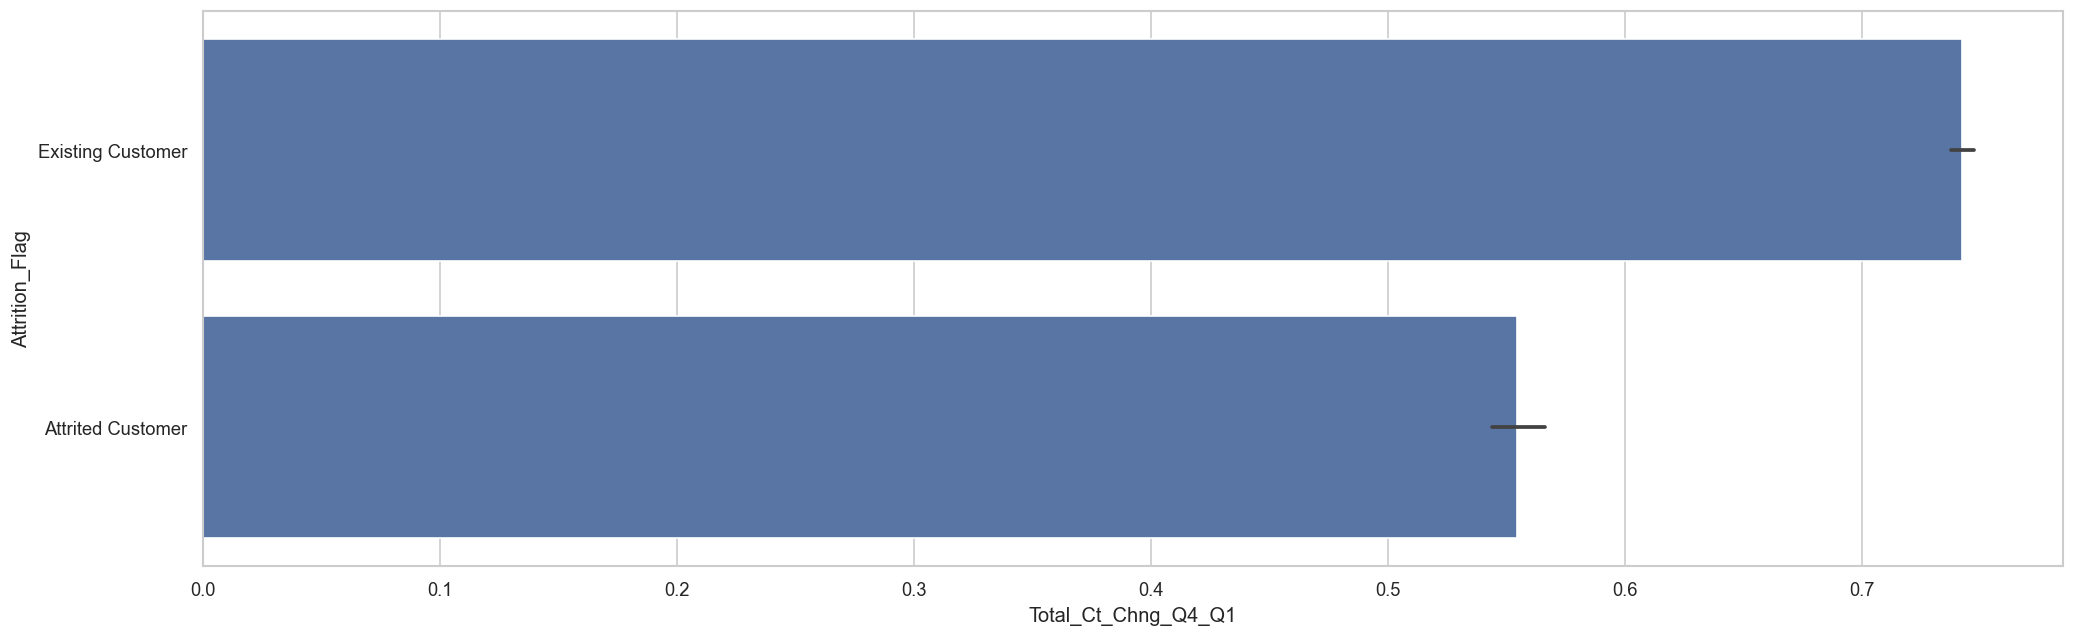

In [20]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, x='Total_Ct_Chng_Q4_Q1', y='Attrition_Flag')

Text(0.5, 0, 'Customer_Age')

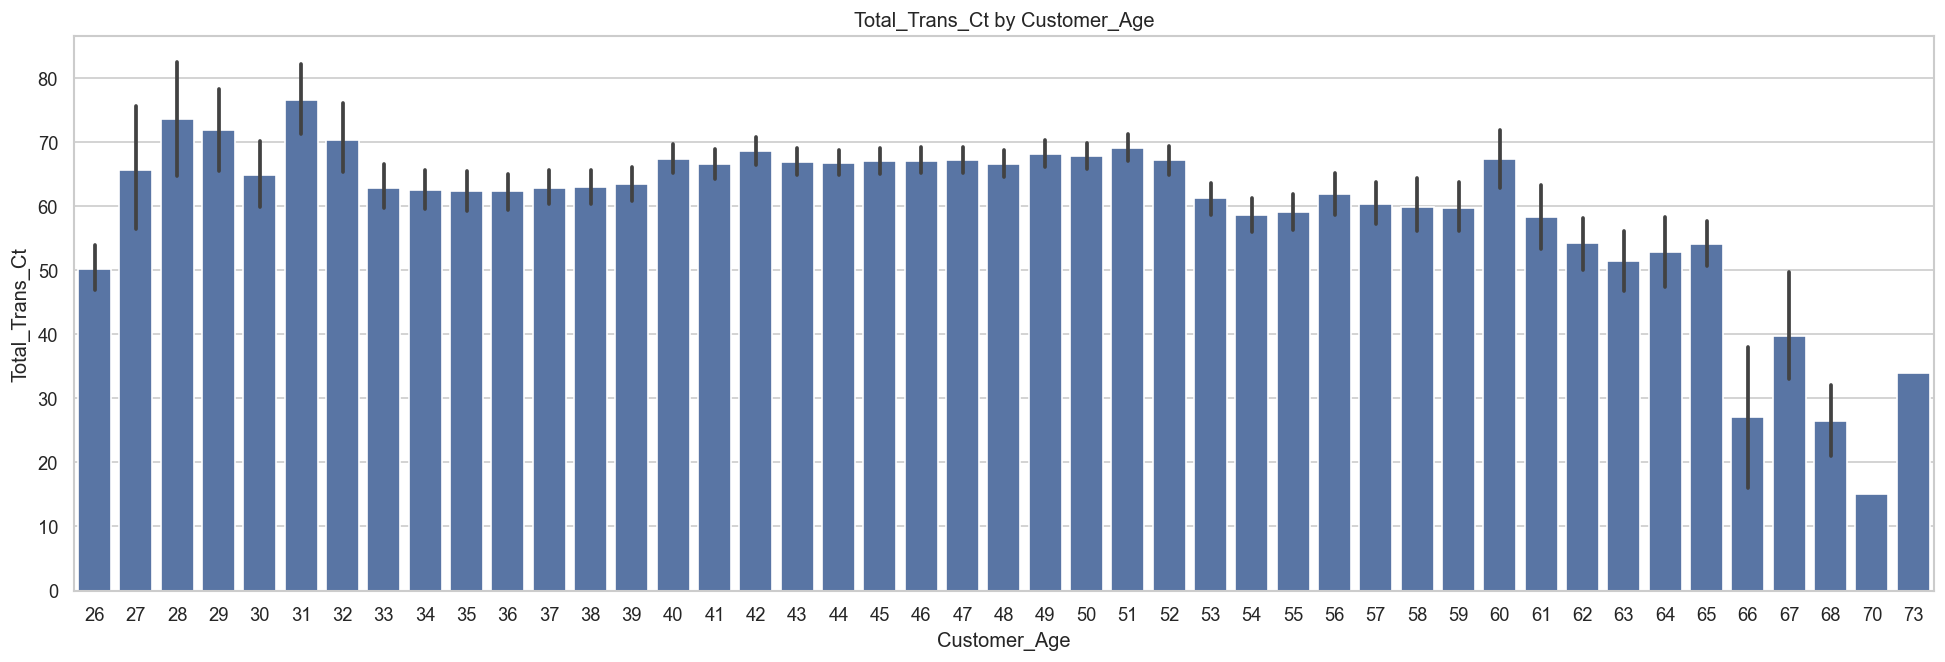

In [21]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, y='Total_Trans_Ct', x='Customer_Age')
plt.title("Total_Trans_Ct by Customer_Age")
plt.xlabel("Customer_Age")

<Axes: xlabel='Customer_Age', ylabel='Total_Ct_Chng_Q4_Q1'>

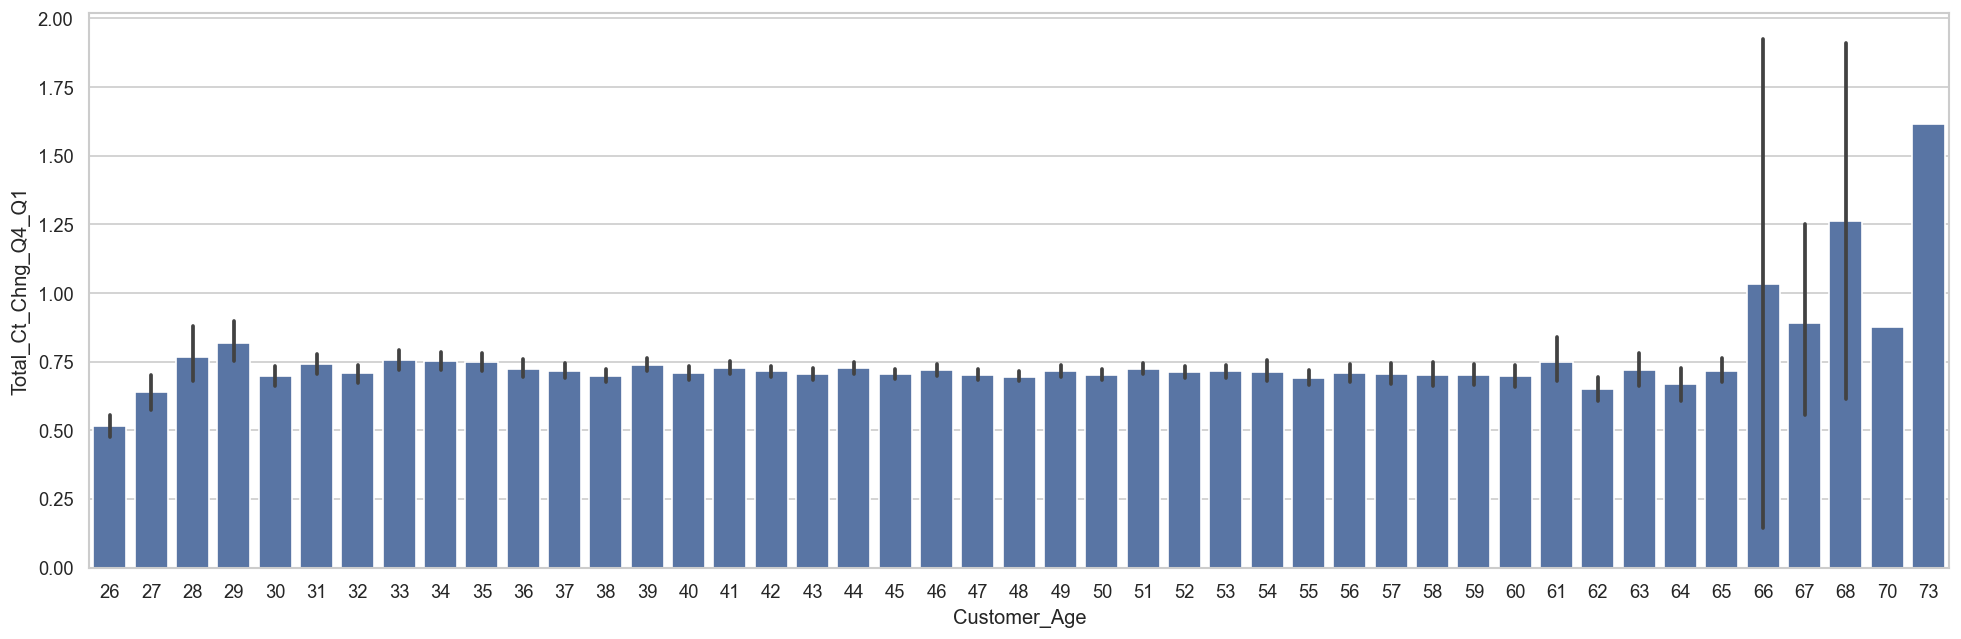

In [22]:
plt.figure(figsize=(20, 6), dpi=120)
sns.barplot(data=df, y='Total_Ct_Chng_Q4_Q1', x='Customer_Age')

**Heatmaap and Barplots- Attrition_Flag Correlation**

Total_Trans_Ct (0.37) Moderatly Positive Correlation with Exisiting Customer

Total_Ct_Chng_Q4_Q1 (0.33) Moderatly Positive Correlation with Exisiting Customer

Total_Trans_Amt (0.17) Weakly Positive Correlation with Exisiting Customer

Avg_Utilization_Ratio (0.18) Weakly Positive Correlation with Exisiting Customer

Total_Relationship_Count (0.15) Weakly Positive Correlation with Exisiting Customer

Near‑zero correlations: Customer_Age, Dependent_count, Months_on_book, Education_Level, Card_Category, Gender, Marital_Status. These are all demographic features

The Heatmap shows that Churn is driven by customer behaviour rather than customer demographic

The data so far shows that existing customers have higher transaction counts and have higher activity change (Q4–Q1), whereas Attrited customers show lower activity and declining engagement.

# **Chi2 Test** #

In [23]:
import pingouin as pg
import scipy
pg.normality(data=df_transformed, alpha=0.05)

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10127.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Customer_Age,0.995998,4.422522e-16,False
Dependent_count,0.936877,5.276381e-54,False
Months_on_book,0.974373,5.070303e-39,False
Total_Relationship_Count,0.920286,2.711124e-58,False
Months_Inactive_12_mon,0.867744,3.517117e-68,False
Contacts_Count_12_mon,0.928326,2.559612e-56,False
Credit_Limit,0.785832,2.476574e-78,False
Total_Revolving_Bal,0.915476,2.136130e-59,False
Avg_Open_To_Buy,0.785679,2.389364e-78,False
Total_Amt_Chng_Q4_Q1,0.984819,1.787347e-31,False


**Total Transaction Count and Attrition Flag**

In [24]:
import scipy.stats as stats
import pandas as pd

expected, observed, stats = pg.chi2_independence(data=df_transformed, x='Total_Trans_Ct', y='Attrition_Flag_Existing Customer')
stats

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-pac

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,2430.079085,125.0,0.0,0.489858,1.0
1,cressie-read,0.666667,2318.709620,125.0,0.0,0.478501,1.0
2,log-likelihood,0.000000,2344.740089,125.0,0.0,0.481179,1.0
3,freeman-tukey,-0.500000,NaN,125.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,125.0,0.0,inf,NaN
5,neyman,-2.000000,NaN,125.0,NaN,NaN,NaN


In [25]:
stats.query("test=='pearson'")['pval'] # Total Transaction Count and Attrition Flag

0    0.0
Name: pval, dtype: float64

**Total Count Change Q4-Q1 and Attrition Flag**

In [26]:
expected, observed, stats = pg.chi2_independence(data=df_transformed, x='Total_Ct_Chng_Q4_Q1', y='Attrition_Flag_Existing Customer')
stats

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-pac

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,2788.948669,658.0,2.853061e-259,0.524783,1.0
1,cressie-read,0.666667,2586.552151,658.0,4.828188e-226,0.505383,1.0
2,log-likelihood,0.000000,2570.269509,658.0,2.093551e-223,0.503789,1.0
3,freeman-tukey,-0.500000,NaN,658.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,658.0,0.000000e+00,inf,NaN
5,neyman,-2.000000,NaN,658.0,NaN,NaN,NaN


In [27]:
stats.query("test=='pearson'")['pval'] #Total Count Change Q4-Q1 and Attrition Flag

0    2.853061e-259
Name: pval, dtype: float64

**Total Relationship Count and Attrition Flag**

In [28]:
expected, observed, stats = pg.chi2_independence(data=df_transformed, x='Total_Relationship_Count', y='Attrition_Flag_Existing Customer')
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,284.067512,5.0,2.661050e-59,0.167483,1.0
1,cressie-read,0.666667,277.327531,5.0,7.466027e-58,0.165484,1.0
2,log-likelihood,0.000000,266.988329,5.0,1.240649e-55,0.162370,1.0
3,freeman-tukey,-0.500000,261.703477,5.0,1.691664e-54,0.160755,1.0
4,mod-log-likelihood,-1.000000,258.329704,5.0,8.964612e-54,0.159715,1.0
5,neyman,-2.000000,256.817235,5.0,1.893060e-53,0.159247,1.0


In [29]:
stats.query("test=='pearson'")['pval'] #Total Relationship Count and Attrition Flag

0    2.661050e-59
Name: pval, dtype: float64

**Total Transation Amount and Attrition Flag**

In [30]:
expected, observed, stats = pg.chi2_independence(data=df_transformed, x='Total_Trans_Amt', y='Attrition_Flag_Existing Customer')
stats

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-pac

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,6883.165102,5032.0,4.501517e-62,0.824430,1.0
1,cressie-read,0.666667,6205.828861,5032.0,5.495363e-28,0.782816,1.0
2,log-likelihood,0.000000,6404.008189,5032.0,9.721122e-37,0.795217,1.0
3,freeman-tukey,-0.500000,NaN,5032.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,5032.0,0.000000e+00,inf,NaN
5,neyman,-2.000000,NaN,5032.0,NaN,NaN,NaN


In [31]:
stats.query("test=='pearson'")['pval'] #Total Transation Amount and Attrition Flag

0    4.501517e-62
Name: pval, dtype: float64

**Average Utilisation Ration and Attrition Flag**

In [32]:
expected, observed, stats = pg.chi2_independence(data=df_transformed, x='Avg_Utilization_Ratio', y='Attrition_Flag_Existing Customer')
stats

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_stats_py.py:7994: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-pac

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,1813.217463,963.0,1.039121e-54,0.423140,1.0
1,cressie-read,0.666667,1799.121333,963.0,2.836559e-53,0.421492,1.0
2,log-likelihood,0.000000,2051.536183,963.0,9.599885e-81,0.450090,1.0
3,freeman-tukey,-0.500000,NaN,963.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,963.0,0.000000e+00,inf,NaN
5,neyman,-2.000000,NaN,963.0,NaN,NaN,NaN


In [33]:
stats.query("test=='pearson'")['pval'] #Average Utilisation Ration and Attrition Flag

0    1.039121e-54
Name: pval, dtype: float64

# **Kruskal Wallis Test** #

**Total Transaction Count and Attrition Flag**

In [86]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [90]:
pg.normality(data=df_transformed, dv='Total_Trans_Ct', group='Attrition_Flag', alpha=0.05)


c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Attrition_Flag,,,
Existing Customer,0.981340,6.213847e-32,False
Attrited Customer,0.969085,3.415159e-18,False


In [91]:
pg.kruskal(data=df_transformed, dv='Total_Trans_Ct', between='Attrition_Flag')

,Source,ddof1,H,p_unc
Kruskal,Attrition_Flag,1,1432.45047,0.0


**Total Count Change Q4-Q1 and Attrition Flag**

In [92]:
pg.normality(data=df_transformed, dv='Total_Ct_Chng_Q4_Q1', group='Attrition_Flag', alpha=0.05)

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Attrition_Flag,,,
Existing Customer,0.984654,2.526999e-29,False
Attrited Customer,0.969103,3.460524e-18,False


In [93]:
pg.kruskal(data=df_transformed, dv='Total_Ct_Chng_Q4_Q1', between='Attrition_Flag')

,Source,ddof1,H,p_unc
Kruskal,Attrition_Flag,1,985.834381,2.154680e-216


**Total Relationship Count and Attrition Flag**

In [95]:
pg.normality(data=df_transformed, dv='Total_Relationship_Count', group='Attrition_Flag', alpha=0.05)

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Attrition_Flag,,,
Existing Customer,0.918331,2.046256e-55,False
Attrited Customer,0.915780,3.681245e-29,False


In [96]:
pg.kruskal(data=df_transformed, dv='Total_Relationship_Count', between='Attrition_Flag')

,Source,ddof1,H,p_unc
Kruskal,Attrition_Flag,1,226.845887,2.905510e-51


**Total Transation Amount and Attrition Flag**

In [97]:
pg.normality(data=df_transformed, dv='Total_Trans_Amt', group='Attrition_Flag', alpha=0.05)

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Attrition_Flag,,,
Existing Customer,0.731671,3.304822e-79,False
Attrited Customer,0.726770,1.464447e-45,False


In [98]:
pg.kruskal(data=df_transformed, dv='Total_Trans_Amt', between='Attrition_Flag')

,Source,ddof1,H,p_unc
Kruskal,Attrition_Flag,1,507.09453,2.718725e-112


**Average Utilisation Ration and Attrition Flag**

In [101]:
pg.normality(data=df_transformed, dv='Avg_Utilization_Ratio', group='Attrition_Flag', alpha=0.05)

c:\Users\Lailah\vscode-project\Credit-Card-Churning-Customers-Analysis-\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8500.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
Attrition_Flag,,,
Existing Customer,0.891954,1.272053e-60,False
Attrited Customer,0.671046,1.703113e-48,False


In [102]:
pg.kruskal(data=df_transformed, dv='Avg_Utilization_Ratio', between='Attrition_Flag')

,Source,ddof1,H,p_unc
Kruskal,Attrition_Flag,1,585.132361,2.868773e-129


---

# Chi2 Summary and Explaination #

**Total Transaction Count vs Attrition Flag**
p-value = 0 which means their is a significant association of Transaction count and Attrition Flag. Customers with low transaction counts are far more likely to churn which can be seen in the heatmap. Transaction count is the strongest predictor for customer churn.

**Total_Ct_Chng_Q4_Q1 vs Attrition_Flag**
p-value = 2.85 × 10⁻²⁵⁹. This means that a change in activity from Q1 → Q4 is strongly associated with churn. Customers whose activity drops are much more likely to leave.

**Total_Relationship_Count vs Attrition_Flag**
p‑value ≈ 4.5 × 10⁻⁶² Number of products a customer holds is significantly associated with churn.

**Total_Trans_Amt vs Attrition_Flag**
p‑value ≈ 1.04 × 10⁻⁵⁴ Spending amount is strongly associated with churn with low spenders are more likely to churn.

This analysis shows tha beahvioural variables correlation with Attrition is meaningful and not due to chance.

# Kruskal Wallis Summary and Explaination #

None of the behavioural variables have a normal distribution for either existing or attrited customers and because of this the Kruskal Wallis test was applied.

Churn in this dataset is driven entirely by behavioural engagement patterns, not by demographic characteristics.  
Customers who transact less, spend less, use their card less, or show declining activity are the ones who churn.

# Hypothesis Test #

**H1. Relationship between months on the books and attrition Customers:** 
This hypothesis can be rejected the correlation is -0.01. This means a customer who has been with the bank for 12 months is just as likely to leave as someone who has been there for 60 months

**H2. Relationship between credit limit and attrition Customers:**
This hypoethesis can be rejected. There is no correlation as shown in the heatmap

**H3. Relationship between product holdings and attrition Customers:**
This Hypothesis can be accepted. With a very small p-value thats <0.05 the statistical significance is massive. The heatmap shows a weakly positive correlation (0.15). This proves that as the number of products increases, the likelihood of staying increases but slightly.

**H4. Gender differences:**
This Hypothesis can be accepted the correlation between gender and attrition is a tiny 0.04

**H5. Relationship between age and attrition:**
Hypothesis rejected the hows a correlation of -0.02. If age were a factor, we would see a much higher number (closer to 0.20 or 0.30). This suggests that churn is not age dependant 

---